<img src="https://dauphine.psl.eu/fileadmin/_processed_/9/2/csm_damier_logo_Dauphine_f7b37a1ff2.jpg" width="200" style="vertical-align:middle" /> <h1>Master 222: Introduction to Python - Session 5</h1>





[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zaltarba/PSL_python_for_finance/blob/main/python_session_5.ipynb)

# Introduction to yfinance

### What is yfinance?

`yfinance` stands for Yahoo Finance, and the `yfinance` library in Python allows you to access financial data from Yahoo! Finance. This can include stock prices, historical data, financial statements, and much more.

### Why use `yfinance`?

If you're interested in financial analysis, algorithmic trading, or just want to understand how the stock market behaves over time, `yfinance` is a great tool to start with. With just a few lines of Python code, you can retrieve vast amounts of financial data.

### Getting Started

Start by importing the library:
```
import yfinance as yf
```
Fetching Data:

You can fetch data for a specific stock or index. Here's how to get the historical data for Apple Inc. (AAPL) for the past month:
```
data = yf.download("AAPL", period="1mo")
print(data)
```

- Fetch the data for AAPL
- Using matplotlib.pyplot, plot the closing prices



In [154]:
import yfinance as yf
import matplotlib.pyplot as plt


/tmp/ipykernel_1364/1839859804.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('AAPL', period='1y')
[*********************100%***********************]  1 of 1 completed
[*********************************************200%***********************************************]  2 of 1 completed

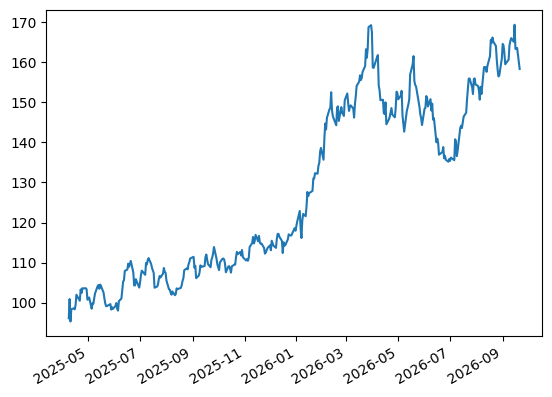

In [155]:
data=yf.download('AAPL', period='1y')
plt.plot(data['Close'])
plt.gcf().autofmt_xdate()
plt.show()

**Exercise: Analyzing Historical Stock Prices**
> Context:
You are a financial analyst at an investment firm. You have been given a dataset containing historical stock prices of several companies over the past decade. Your task is to clean, analyze, and visualize the data to help the firm make informed investment decisions.

> Dataset:
The dataset contains the following columns: 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'.


**Data Loading and Inspection**:

- Fetch the historical stock price data for 'AAPL'.
- Display the first 10 rows of the dataset.
- Check for any missing values in the dataset.

**Data Cleaning**:

- Handle any missing values: You can either fill them using methods such as forward fill, backward fill, or interpolation, or you can choose to drop rows with missing values.
- Convert the 'Date' column to a datetime format if it isn't already..

**Data Transformation**:

- Make the 'Date' column the index of the DataFrame to facilitate time series analysis.
- Compute a new column 'Price_Average', which is the arithmetic mean of the 'High' and 'Low' prices for each trading day.

**Data Analysis**:

- Determine the specific date when the trading volume for Apple Inc. was at its peak.
- Compute the monthly average of the 'Close' price to understand monthly performance trends.

**Data Aggregation**:

- Calculate the total trading volume and average closing price for each company over the period.

**File I/O**:

- Save the cleaned and transformed dataset to a new CSV file.
- Save the plots as image files.

**Bonus**:

- Use a simple linear regression model to attempt predictions of future stock prices based on historical data. This will provide a rudimentary forecast which can be enhanced with more complex models.
- Implement a basic moving average trading strategy. For instance, consider using a 50-day and a 200-day moving average. Generate buy signals when the 50-day moving average crosses above the 200-day moving average, and sell signals when it crosses below. Backtest this strategy to gauge its historical performance.

In [156]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [157]:
tickers=['AAPL','MSFT','TSLA','NVO','MC.PA','OR.PA','NVDA','BNP.PA','TTE.PA']
data=yf.download(tickers,period='10y')
data.head(10)

/tmp/ipykernel_1364/4008341938.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers,period='10y')
[*********************100%***********************]  9 of 9 completed


Price            Close                                                \
Ticker              GL         LEN         MMM         MO        NRG   
Date                                                                   
2025-04-08  112.126808  100.024529  123.675247  50.339417  84.288368   
2025-04-09  121.370903  105.562019  134.529434  51.064255  95.562782   
2025-04-10  117.382278  101.510910  129.326019  51.082375  91.147209   
2025-04-11  118.273033  102.239525  132.224365  51.327000  92.697563   
2025-04-14  119.985283  103.045868  132.282730  51.761898  94.120369   
2025-04-15  121.529266  102.084084  131.553253  52.115250  95.288048   
2025-04-16  119.975388   99.830231  126.884827  51.888744  96.249657   
2025-04-17  120.005074  101.744072  126.641685  52.695118  96.023972   
2025-04-21  115.966965  100.753151  122.634575  52.214920  91.343452   
2025-04-22  120.430664  104.843117  132.593979  53.293102  96.946335   

Price                                                            High  ...  \
Ticker            TPR        ULTA         VST         WTW          GL  ...   
Date                                                                   ...   
2025-04-08  59.340057  328.010010  101.362068  297.434357  118.411609  ...   
2025-04-09  65.881172  363.190002  117.063820  309.989075  121.776697  ...   
2025-04-10  62.591034  354.950012  108.374794  311.791077  119.757638  ...   
2025-04-11  62.081844  361.459991  110.804939  316.812927  119.015333  ...   
2025-04-14  62.453945  366.250000  111.776993  322.996765  121.994439  ...   
2025-04-15  62.610615  358.089996  114.812202  322.149963  122.509100  ...   
2025-04-16  61.562866  349.589996  114.931229  319.757172  122.123106  ...   
2025-04-17  62.316860  357.750000  114.484879  316.084290  121.450082  ...   
2025-04-21  61.866425  365.670013  105.656982  310.924561  119.757642  ...   
2025-04-22  63.570236  378.670013  111.717476  319.707947  120.430664  ...   

Price             Open   Volume                                       \
Ticker             WTW       GL      LEN      MMM        MO      NRG   
Date                                                                   
2025-04-08  304.228686   854900  5685000  5496800  12315600  3618400   
2025-04-09  290.206732  1146100  5647600  6428100  15940600  4840800   
2025-04-10  310.176177   746800  2640100  4757100  13148000  2577000   
2025-04-11  308.689266   535000  2766100  3337600   9760300  1634900   
2025-04-14  317.827162   523500  1984900  3815800   9782600  1981700   
2025-04-15  323.873164   456000  1508900  2541700   6384000  1513700   
2025-04-16  323.095242   553100  2785500  5635500   8526100  2217500   
2025-04-17  319.038348   563100  2736800  4952000   8765700  1945900   
2025-04-21  315.611647   763400  2176600  5971800   6727900  1916000   
2025-04-22  316.084308   483500  2584300  7943800   9475200  3561500   

Price                                             
Ticker           TPR     ULTA       VST      WTW  
Date                                              
2025-04-08  10731800  1249900  11458100  1257400  
2025-04-09  12486300  1653000  14023800  1048800  
2025-04-10   5762000  1069600   8735400   694000  
2025-04-11   5317800   943200   5268000   605400  
2025-04-14   8250400  1004500   5007400   633600  
2025-04-15   3841900   658300   4279400   553600  
2025-04-16   3163500   791100   5956700   528700  
2025-04-17   4165700   741700   4853100   658700  
2025-04-21   3679900   838100   6092400   655900  
2025-04-22   7020900   728600   4882200   643000  

[10 rows x 45 columns]

[*********************100%***********************]  9 of 9 completed

In [158]:
data['Close'].isna().sum()

,0
Ticker,
GL,0
LEN,0
MMM,0
MO,0
NRG,0
TPR,0
ULTA,0
VST,0
WTW,0


In [159]:
data=data.ffill()
data.isna().any()

Price   Ticker
Close   GL        False
        LEN       False
        MMM       False
        MO        False
        NRG       False
        TPR       False
        ULTA      False
        VST       False
        WTW       False
High    GL        False
        LEN       False
        MMM       False
        MO        False
        NRG       False
        TPR       False
        ULTA      False
        VST       False
        WTW       False
Low     GL        False
        LEN       False
        MMM       False
        MO        False
        NRG       False
        TPR       False
        ULTA      False
        VST       False
        WTW       False
Open    GL        False
        LEN       False
        MMM       False
        MO        False
        NRG       False
        TPR       False
        ULTA      False
        VST       False
        WTW       False
Volume  GL        False
        LEN       False
        MMM       False
        MO        False
        NRG       False
        TPR       False
        ULTA      False
        VST       False
        WTW       False
dtype: bool

In [160]:
print(data.index.dtype)

datetime64[ns]


In [161]:
price_average=(data['High']+data['Low'])/2
price_average.head(10)

Ticker,GL,LEN,MMM,MO,NRG,TPR,ULTA,VST,WTW
Date,,,,,,,,,
2025-04-08,114.744651,102.662126,125.800362,50.760724,86.579555,61.827249,339.285004,105.285023,301.550338
2025-04-09,115.694790,101.637198,127.735846,50.778853,89.155298,62.096532,346.760010,109.207988,300.688721
2025-04-10,116.828031,101.316615,128.611154,50.864924,91.662361,62.688957,351.589996,110.368508,309.299807
2025-04-11,116.847820,100.102251,130.400756,51.132200,91.706514,61.979024,356.979996,108.161530,312.608328
2025-04-14,120.514786,102.666988,132.623137,51.616931,94.498148,63.080640,367.889999,113.428500,321.662520
2025-04-15,121.410496,102.963280,132.569621,52.128840,95.425421,62.576344,363.875000,113.435943,322.927859
2025-04-16,120.514790,100.855148,128.552817,52.210387,95.415606,61.739126,352.635010,113.855016,321.431120
2025-04-17,120.247557,101.068884,127.910916,52.532031,97.029738,61.890905,354.385010,116.141350,316.591402
2025-04-21,117.218980,100.519996,123.757925,52.310054,92.059760,61.141808,358.275009,107.788573,312.381877


In [162]:
max_volume_date=data['Volume'].idxmax()
max_volume_date

,0
Ticker,
GL,2026-07-23
LEN,2025-11-20
MMM,2026-01-20
MO,2026-03-20
NRG,2026-08-04
TPR,2025-08-26
ULTA,2025-05-30
VST,2026-01-09
WTW,2026-02-12


In [163]:
monthly_close_mean = data['Close'].resample('ME').mean()
monthly_volume_sum = data['Volume'].resample('ME').sum()

monthly_data = pd.concat([monthly_close_mean, monthly_volume_sum], axis=1, keys=['Close', 'Volume'])
monthly_data.head(10)

Close                                                 \
Ticker              GL         LEN         MMM         MO         NRG   
Date                                                                    
2025-04-30  120.001363  103.427158  131.071847  52.273809   97.907335   
2025-05-31  119.567235  105.840511  142.963342  53.661555  141.236956   
2025-06-30  120.049117  106.547237  143.218293  54.318305  152.642525   
2025-07-31  124.380384  110.736120  149.929553  54.526938  152.605222   
2025-08-31  138.064176  125.165884  150.854609  60.339952  150.768813   
2025-09-30  141.270097  129.575193  152.202313  61.063003  157.945840   
2025-10-31  134.814992  122.616982  156.462207  60.121734  165.634516   
2025-11-30  131.867955  120.292407  164.492352  54.319478  165.479285   
2025-12-31  136.803103  113.585145  162.456303  54.939868  160.143855   
2026-01-31  139.085026  111.580433  160.219579  57.087969  151.340099   

                                                              Volume  \
Ticker             TPR        ULTA         VST         WTW        GL   
Date                                                                   
2025-04-30   64.336475  368.956253  116.517648  310.486349  10476600   
2025-05-31   77.148143  408.676193  149.627832  305.092380  14090600   
2025-06-30   81.121066  466.305000  177.076467  298.337236   9736600   
2025-07-31   99.326919  492.627729  192.231522  303.654320  17234300   
2025-08-31  102.454516  516.926669  197.997799  325.659376  12520000   
2025-09-30  107.505454  528.584281  200.418431  331.094924  10825900   
2025-10-31  113.088068  537.034346  198.151091  330.720788  14473200   
2025-11-30  103.352768  518.816846  178.349736  317.122292   9786600   
2025-12-31  121.149292  589.615462  165.718653  323.543943  10960600   
2026-01-31  129.267549  657.758997  163.079041  323.005019  10332400   

                                                                           \
Ticker            LEN       MMM         MO       NRG        TPR      ULTA   
Date                                                                        
2025-04-30   42773100  68078300  156498800  37828200   87370700  13667600   
2025-05-31   51302800  65870500  162509500  81538500   91685900  19324600   
2025-06-30   68078600  55918200  178501700  68686000   65341700  15628900   
2025-07-31   69674600  90785900  211743400  59313500   87278500  12536900   
2025-08-31   65735800  63435700  156209100  59855800  108285200  16461400   
2025-09-30   88951500  57468700  174649800  50043800   71497500  15103700   
2025-10-31   83247000  74554100  197374900  50111100   52258800  12207700   
2025-11-30  165729600  58772500  159537700  40276400   72484000   9895400   
2025-12-31  122632400  52125000  198585100  37079800   60454600  19214600   
2026-01-31   67712100  85355800  229113400  40005000   43061000  11426200   

                                 
Ticker            VST       WTW  
Date                             
2025-04-30  101065800  13262300  
2025-05-31  136587200  11317300  
2025-06-30  106715000  13404200  
2025-07-31  108528400  16099400  
2025-08-31   88371500  12613500  
2025-09-30  103151500  11257900  
2025-10-31  106761900  13134100  
2025-11-30   82115700  13236600  
2025-12-31   91628300  14578600  
2026-01-31  125723100   9888000

[***********************************************************************311%**************************************************************************]  28 of 9 completed

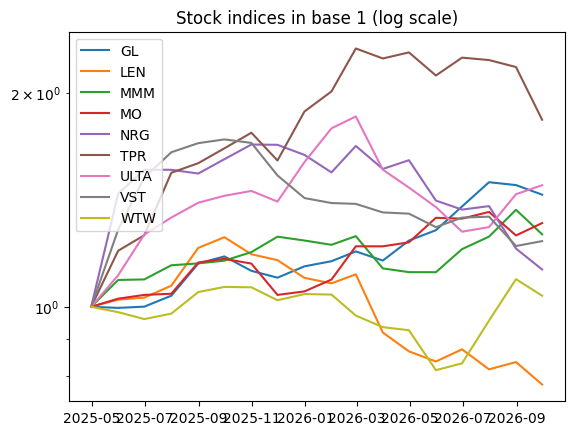

In [164]:
monthly_prices_rebased=monthly_data['Close']/monthly_data['Close'].iloc[0]
plt.plot(monthly_prices_rebased)
plt.title('Stock indices in base 1 (log scale)')
plt.legend(monthly_prices_rebased.columns)
plt.yscale('log')
plt.savefig("stock_prices.png", dpi=300, bbox_inches="tight")
plt.show()

[*****************************************************************************************************433%*******************************************************************************************************]  39 of 9 completed

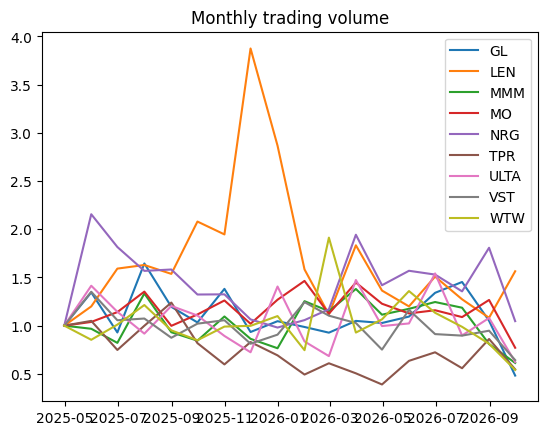

In [165]:
monthly_volume_rebased=monthly_data['Volume']/monthly_data['Volume'].iloc[0]
plt.plot(monthly_volume_rebased)
plt.title('Monthly trading volume')
plt.legend(monthly_volume_rebased.columns)
plt.savefig("monthly_volume.png", dpi=300, bbox_inches="tight")
plt.show()

In [166]:
data.to_csv('clean_data.csv', index='False')

**Exercice TO DO: Momentum Strategy on 50 Stocks**

## Objective
Explore the performance of a simple momentum strategy on a subset of 50 stocks.

## Procedure

### 1. Stock Selection
- Use `pandas` to fetch the list of all tickers from [this link](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies)
    - Use pd.read_html
- Randomly select 50 stocks from this list.

### 2. Data Collection
- For each stock, download the daily adjusted closing prices for the last 365 days.
- Store this data in a pandas DataFrame with dates as the index.

### 3. Momentum Calculation
- Define momentum as the percentage change in the stock price over the previous n days (e.g., n=21 for a month).
- Using pandas, compute the momentum for each stock for each day.
- Rank the stocks based on their momentum every day.

### 4. Strategy

1. At the beginning of each month, buy the top 10 stocks based on momentum from the previous month.
2. At the end of the month, sell all the stocks.
3. Repeat this process for each month in your dataset.

### 5. Performance Analysis

- Calculate the monthly and annualized return of this strategy.
- Compare the strategy's performance against a benchmark (e.g., S&P 500).
- Plot the cumulative returns of your strategy and the benchmark.

### 6. Risk Analysis
- Using numpy, compute the standard deviation of the monthly returns to get a measure of the strategy's risk.
- Calculate the Sharpe Ratio.

## Hints

- To get the tickers list:
```python
import requests

# URL of the Wikipedia page
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Set headers to mimic a browser
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send the HTTP request with custom headers
response = requests.get(url, headers=headers)

# Use pandas to read the HTML from the response content
tables = pd.read_html(response.text)
```

In [167]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)

/tmp/ipykernel_1364/2158521338.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
[**********************************************************************************************************456%*************************************************************************************************************]  41 of 9 completed

In [174]:
tickers=tables[0]['Symbol'].to_list()
tickers_subset=np.random.choice(tickers,50,replace='False')
print(tickers_subset)

['FICO' 'AEP' 'AMGN' 'QCOM' 'WDC' 'BKNG' 'NWS' 'CRH' 'P' 'HRL' 'CCI'
 'SCHW' 'CARR' 'MRNA' 'SWKS' 'GL' 'STZ' 'EXC' 'CIEN' 'MRVL' 'COF' 'INTU'
 'RMD' 'ERIE' 'TRMB' 'DOW' 'VLO' 'OKE' 'NSC' 'MGM' 'NOC' 'CMS' 'BAC' 'MLM'
 'INTU' 'NWS' 'OXY' 'TGT' 'INCY' 'ALB' 'ROP' 'SW' 'WELL' 'VEEV' 'SYK'
 'APA' 'AMGN' 'NWS' 'WEC' 'MCK']


In [181]:
data=yf.download(list(tickers_subset),period="365d")
prices=data['Close']
prices.head(10)

/tmp/ipykernel_1364/1528857089.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(list(tickers_subset),period="365d")
[*********************100%***********************]  46 of 46 completed


Ticker,AEP,ALB,AMGN,APA,BAC,BKNG,CARR,CCI,CIEN,CMS,...,SW,SWKS,SYK,TGT,TRMB,VEEV,VLO,WDC,WEC,WELL
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-08,96.567947,49.590229,268.131439,13.159221,33.909332,164.487350,54.372093,88.233093,54.029999,67.062340,...,36.384373,46.737980,333.256897,83.436623,55.119999,209.389999,101.301804,31.396132,97.885796,133.299728
2025-04-09,97.588165,59.076462,278.492676,15.672884,35.961521,182.348434,59.481403,88.893723,61.990002,67.960449,...,40.662090,57.254025,358.544739,91.831047,61.490002,217.039993,111.626534,36.122971,99.226448,138.182861
2025-04-10,98.398621,53.449200,269.231628,13.693844,34.703102,177.541992,57.797874,88.540138,58.360001,68.361740,...,38.366035,51.145790,344.142517,87.149712,58.040001,210.639999,104.990578,34.699940,100.319870,138.495361
2025-04-11,99.762085,55.364029,273.603851,14.106534,34.799908,181.171707,58.003426,89.945091,58.779999,68.619713,...,38.870975,53.710678,346.009491,87.215523,58.220001,218.000000,106.618271,34.232239,101.698540,139.335251
2025-04-14,101.621376,56.067440,281.200226,14.256604,35.496868,179.998932,59.305229,92.894569,58.500000,70.253510,...,39.480717,54.831635,349.111237,88.973373,59.490002,223.660004,106.261902,35.645309,103.143776,142.186996
2025-04-15,101.716721,52.765327,282.520508,13.965845,36.774647,182.195190,59.187778,93.517960,59.380001,69.470039,...,39.166317,54.527649,342.571899,86.557510,59.590000,222.720001,103.584419,35.754776,102.934586,143.163651
2025-04-16,100.992073,51.358517,270.408447,14.416052,36.135757,179.366928,57.934910,94.206474,58.869999,68.954117,...,38.842392,53.064705,342.443542,85.034660,58.279999,220.660004,103.179886,35.446289,102.078865,142.226074
2025-04-17,102.698792,51.690681,265.289917,15.110125,36.213192,180.649521,58.629856,96.383705,60.139999,69.661140,...,39.394974,53.178699,342.275604,87.525734,58.230000,215.949997,106.001854,36.331944,103.058205,143.827759
2025-04-21,100.620216,51.798145,261.836121,14.537984,35.738869,175.290054,56.946327,95.025261,57.840000,68.887230,...,38.851921,53.938667,335.449829,88.155548,56.220001,210.080002,104.826851,35.784622,101.698540,140.292358


In [188]:
momentum = prices.pct_change(periods=21)
momentum.iloc[20:25]

Ticker,AEP,ALB,AMGN,APA,BAC,BKNG,CARR,CCI,CIEN,CMS,...,SW,SWKS,SYK,TGT,TRMB,VEEV,VLO,WDC,WEC,WELL
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-08,0.038606,0.131600,-0.029294,0.172149,0.187554,0.240414,0.273231,0.089107,0.384046,0.034335,...,0.091909,0.367683,0.133651,0.092046,0.222424,0.143942,0.157349,0.404120,0.048664,0.086160
2025-05-09,0.031888,-0.042004,-0.086674,0.017002,0.124899,0.098828,0.179382,0.099016,0.205678,0.023825,...,-0.018275,0.131740,0.049453,-0.013205,0.107822,0.092195,0.060656,0.214876,0.031238,0.054350
2025-05-12,-0.012686,0.125388,-0.023631,0.232899,0.209484,0.155819,0.247714,0.055906,0.353838,-0.013164,...,0.117457,0.356612,0.113924,0.090282,0.215369,0.146221,0.197046,0.335532,-0.005118,0.026937
2025-05-13,-0.039969,0.091583,-0.054304,0.247515,0.231711,0.147364,0.263777,0.017068,0.371045,-0.028658,...,0.126961,0.284047,0.106343,0.068010,0.223806,0.106422,0.220506,0.424709,-0.031788,0.018294
2025-05-14,-0.066716,0.064297,-0.107648,0.214991,0.220071,0.144774,0.214676,-0.016126,0.359487,-0.057414,...,0.124759,0.251559,0.093090,0.017951,0.198016,0.074399,0.217439,0.373534,-0.049324,-0.010479
2025-05-15,-0.039029,0.116830,-0.079953,0.212300,0.168202,0.135568,0.219077,0.002587,0.343887,-0.017545,...,0.134274,0.259233,0.130911,0.066244,0.195503,0.084770,0.258670,0.384637,-0.022515,0.006689
2025-05-16,-0.018513,0.145330,-0.027677,0.163199,0.197160,0.170944,0.281712,0.010568,0.379990,-0.002237,...,0.154651,0.312567,0.137133,0.102222,0.233528,0.100245,0.267059,0.403425,0.000336,0.025950
2025-05-19,-0.027892,0.119637,0.003598,0.092733,0.196739,0.175953,0.270037,-0.005889,0.346691,-0.005454,...,0.132353,0.302608,0.139076,0.064442,0.231152,0.109701,0.220516,0.389209,-0.001818,0.027690


In [190]:
momentum=momentum.dropna()
momentum.head()

Ticker,AEP,ALB,AMGN,APA,BAC,BKNG,CARR,CCI,CIEN,CMS,...,SW,SWKS,SYK,TGT,TRMB,VEEV,VLO,WDC,WEC,WELL
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-08,0.038606,0.131600,-0.029294,0.172149,0.187554,0.240414,0.273231,0.089107,0.384046,0.034335,...,0.091909,0.367683,0.133651,0.092046,0.222424,0.143942,0.157349,0.404120,0.048664,0.086160
2025-05-09,0.031888,-0.042004,-0.086674,0.017002,0.124899,0.098828,0.179382,0.099016,0.205678,0.023825,...,-0.018275,0.131740,0.049453,-0.013205,0.107822,0.092195,0.060656,0.214876,0.031238,0.054350
2025-05-12,-0.012686,0.125388,-0.023631,0.232899,0.209484,0.155819,0.247714,0.055906,0.353838,-0.013164,...,0.117457,0.356612,0.113924,0.090282,0.215369,0.146221,0.197046,0.335532,-0.005118,0.026937
2025-05-13,-0.039969,0.091583,-0.054304,0.247515,0.231711,0.147364,0.263777,0.017068,0.371045,-0.028658,...,0.126961,0.284047,0.106343,0.068010,0.223806,0.106422,0.220506,0.424709,-0.031788,0.018294
2025-05-14,-0.066716,0.064297,-0.107648,0.214991,0.220071,0.144774,0.214676,-0.016126,0.359487,-0.057414,...,0.124759,0.251559,0.093090,0.017951,0.198016,0.074399,0.217439,0.373534,-0.049324,-0.010479
2025-05-15,-0.039029,0.116830,-0.079953,0.212300,0.168202,0.135568,0.219077,0.002587,0.343887,-0.017545,...,0.134274,0.259233,0.130911,0.066244,0.195503,0.084770,0.258670,0.384637,-0.022515,0.006689
2025-05-16,-0.018513,0.145330,-0.027677,0.163199,0.197160,0.170944,0.281712,0.010568,0.379990,-0.002237,...,0.154651,0.312567,0.137133,0.102222,0.233528,0.100245,0.267059,0.403425,0.000336,0.025950
2025-05-19,-0.027892,0.119637,0.003598,0.092733,0.196739,0.175953,0.270037,-0.005889,0.346691,-0.005454,...,0.132353,0.302608,0.139076,0.064442,0.231152,0.109701,0.220516,0.389209,-0.001818,0.027690
2025-05-20,-0.008289,0.118823,0.013740,0.131148,0.210455,0.196738,0.292409,0.007735,0.401279,0.005859,...,0.137042,0.290595,0.147119,0.058240,0.286197,0.146135,0.225024,0.407954,0.014451,0.057575


In [191]:
ranked_momentum = momentum.rank(axis=1, ascending=False)
ranked_momentum.head()

Ticker,AEP,ALB,AMGN,APA,BAC,BKNG,CARR,CCI,CIEN,CMS,...,SW,SWKS,SYK,TGT,TRMB,VEEV,VLO,WDC,WEC,WELL
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-08,39.0,26.0,45.0,17.0,15.0,9.0,4.0,32.0,2.0,40.0,...,31.0,3.0,24.0,30.0,10.0,23.0,20.0,1.0,37.0,33.0
2025-05-09,26.0,42.0,44.0,31.0,9.0,12.0,3.0,11.0,2.0,29.0,...,40.0,5.0,22.0,38.0,10.0,14.0,20.0,1.0,27.0,21.0
2025-05-12,41.0,24.0,43.0,7.0,10.0,18.0,5.0,32.0,2.0,42.0,...,25.0,1.0,28.0,30.0,9.0,21.0,13.0,3.0,40.0,36.0
2025-05-13,42.0,25.0,43.0,7.0,8.0,16.0,5.0,34.0,2.0,40.0,...,18.0,4.0,23.0,30.0,10.0,22.0,11.0,1.0,41.0,33.0
2025-05-14,41.0,27.0,44.0,8.0,6.0,15.0,9.0,36.0,3.0,40.0,...,18.0,5.0,23.0,31.0,11.0,26.0,7.0,1.0,39.0,34.0
